# Analysis of memory-pool simulations

## Set up

In [1]:
suppressMessages({
    require(RColorBrewer, quietly=TRUE)
    require(data.table, quietly=TRUE)
    require(ggplot2, quietly=TRUE)
    require(ggraph, quietly=TRUE)
    require(igraph, quietly=TRUE)
    require(magrittr, quietly=TRUE)
    require(tidygraph, quietly=TRUE)
})

## Adversarial nodes, with 2 ms delay for front-running and at 6 TPS

### Read data

In [2]:
adversariesLeios <- fread("adversaries.tsv.gz", stringsAsFactors=TRUE)
adversariesLeios[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversariesLeios[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversariesLeios[, `Txs`:=`Honest txs`+`Adversarial txs`]

In [3]:
adversariesPraos <- fread("../experiment-praos/adversaries.tsv.gz", stringsAsFactors=TRUE)
adversariesPraos[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversariesPraos[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversariesPraos[, `Txs`:=`Honest txs`+`Adversarial txs`]

In [4]:
adversaries <- rbind(
    cbind(`Protocol`=factor("Praos", levels=c("Praos", "Leios")), adversariesPraos),
    cbind(`Protocol`=factor("Leios", levels=c("Praos", "Leios")), adversariesLeios)
)
adversaries %>% summary

  Protocol    Adversarial nodes     RB ID      RB honest txs  
 Praos:1834   Min.   :  0.0     B0     : 202   Min.   : 0.00  
 Leios:1730   1st Qu.:125.0     B1     : 202   1st Qu.: 2.00  
              Median :250.0     B2     : 202   Median :60.00  
              Mean   :250.6     B3     : 202   Mean   :41.23  
              3rd Qu.:375.0     B4     : 202   3rd Qu.:60.00  
              Max.   :500.0     B5     : 202   Max.   :60.00  
                                (Other):2352                  
 RB adversarial txs     EB ID      EB honest txs     EB adversarial txs
 Min.   :0.0000            :1037   Min.   :   0.00   Min.   : 0.0000   
 1st Qu.:0.0000     EB3    :  55   1st Qu.:   0.00   1st Qu.: 0.0000   
 Median :0.0000     EB1    :  54   Median :   0.00   Median : 0.0000   
 Mean   :0.0188     EB2    :  54   Mean   :  34.92   Mean   : 0.1745   
 3rd Qu.:0.0000     EB4    :  53   3rd Qu.:   0.00   3rd Qu.: 0.0000   
 Max.   :2.0000     (Other): 477   Max.   :1367.00   Max.   :24.

### Trends

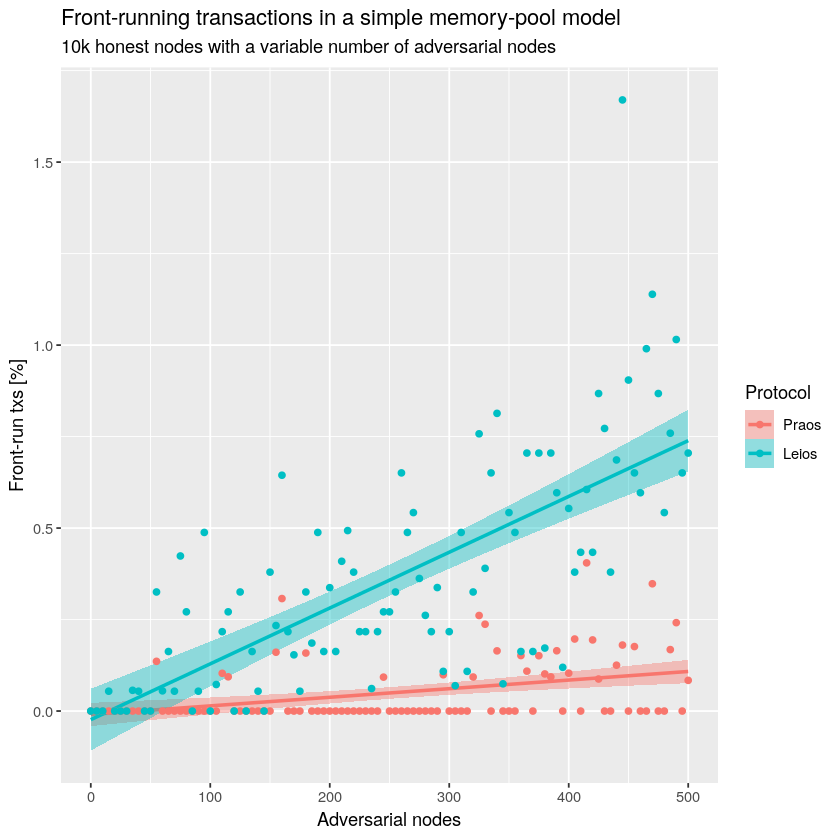

In [5]:
ggplot(
    adversaries[
        ,
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Protocol`, `Adversarial nodes`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`, color=`Protocol`, fill=`Protocol`)
) +
    geom_smooth(formula=y~x, method="lm") +
    geom_point() +
    ggtitle(
        "Front-running transactions in a simple memory-pool model",
        "10k honest nodes with a variable number of adversarial nodes"
    )

In [6]:
ggsave("adversarial-scatter-2ms-delay.png", units="in", dpi=150, width=8, height=6)

In [7]:
ggsave("adversarial-scatter-2ms-delay.svg", units="in", dpi=150, width=8, height=6)

### Regression model

### Leios

In [8]:
lm(
    `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`,
    data=adversaries[
        `Protocol` == "Leios",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Fraction adversarial nodes [%]`=100*`Adversarial nodes`/(10000+`Adversarial nodes`))
    ]
) %>% summary


Call:
lm(formula = `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`, 
    data = adversaries[Protocol == "Leios", .(`Front-run txs [%]` = 100 * 
        sum(`Adversarial txs`)/sum(Txs)), .(`Fraction adversarial nodes [%]` = 100 * 
        `Adversarial nodes`/(10000 + `Adversarial nodes`))])

Residuals:
     Min       1Q   Median       3Q      Max 
-0.45876 -0.12876 -0.01565  0.11821  1.01809 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -0.02863    0.04320  -0.663    0.509    
`Fraction adversarial nodes [%]`  0.15971    0.01549  10.311   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2161 on 99 degrees of freedom
Multiple R-squared:  0.5178,	Adjusted R-squared:  0.513 
F-statistic: 106.3 on 1 and 99 DF,  p-value: < 2.2e-16


### Praos

In [9]:
lm(
    `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`,
    data=adversaries[
        `Protocol` == "Praos",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Fraction adversarial nodes [%]`=100*`Adversarial nodes`/(10000+`Adversarial nodes`))
    ]
) %>% summary


Call:
lm(formula = `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`, 
    data = adversaries[Protocol == "Praos", .(`Front-run txs [%]` = 100 * 
        sum(`Adversarial txs`)/sum(Txs)), .(`Fraction adversarial nodes [%]` = 100 * 
        `Adversarial nodes`/(10000 + `Adversarial nodes`))])

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10592 -0.05222 -0.01904  0.02147  0.31695 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -0.010145   0.016253  -0.624    0.534    
`Fraction adversarial nodes [%]`  0.024609   0.005827   4.223 5.36e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.08129 on 99 degrees of freedom
Multiple R-squared:  0.1527,	Adjusted R-squared:  0.1441 
F-statistic: 17.84 on 1 and 99 DF,  p-value: 5.357e-05
